In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('ecommerce_sales_data.csv')
df.head()
df.info()
print(df.columns)

<class 'pandas.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order Date    3500 non-null   str    
 1   Product Name  3500 non-null   str    
 2   Category      3500 non-null   str    
 3   Region        3500 non-null   str    
 4   Quantity      3500 non-null   int64  
 5   Sales         3500 non-null   int64  
 6   Profit        3500 non-null   float64
dtypes: float64(1), int64(2), str(4)
memory usage: 191.5 KB
Index(['Order Date', 'Product Name', 'Category', 'Region', 'Quantity', 'Sales',
       'Profit'],
      dtype='str')


In [4]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df.head()
print("Start Date:", df['Order Date'].min())
print("End Date:", df['Order Date'].max())

Start Date: 2022-01-01 00:00:00
End Date: 2024-12-31 00:00:00


In [5]:
monthly_sales = df.groupby(
    df['Order Date'].dt.to_period('M')
)['Sales'].sum().reset_index()
monthly_sales['Order Date'] = monthly_sales['Order Date'].astype(str)
monthly_sales['Order Date'] = pd.to_datetime(monthly_sales['Order Date'])

monthly_sales.head()

,Order Date,Sales
0,2022-01-01,341544
1,2022-02-01,208775
2,2022-03-01,294660
3,2022-04-01,230624
4,2022-05-01,314295


In [6]:
monthly_sales['Month_Number'] = range(1, len(monthly_sales) + 1)

monthly_sales.head()

,Order Date,Sales,Month_Number
0,2022-01-01,341544,1
1,2022-02-01,208775,2
2,2022-03-01,294660,3
3,2022-04-01,230624,4
4,2022-05-01,314295,5


In [7]:
X = monthly_sales[['Month_Number']]
y = monthly_sales['Sales']
model = LinearRegression()
model.fit(X, y)
monthly_sales['Predicted_Sales'] = model.predict(X)

monthly_sales.head()

,Order Date,Sales,Month_Number,Predicted_Sales
0,2022-01-01,341544,1,274241.021021
1,2022-02-01,208775,2,275503.249979
2,2022-03-01,294660,3,276765.478936
3,2022-04-01,230624,4,278027.707894
4,2022-05-01,314295,5,279289.936851


In [8]:
mae = mean_absolute_error(
    monthly_sales['Sales'],
    monthly_sales['Predicted_Sales']
)

r2 = r2_score(
    monthly_sales['Sales'],
    monthly_sales['Predicted_Sales']
)

print("Mean Absolute Error:", round(mae,2))
print("R² Score:", round(r2,2))

Mean Absolute Error: 35867.67
R² Score: 0.08


In [13]:
future_months = pd.DataFrame({
    'Month_Number': range(
        len(monthly_sales)+1,
        len(monthly_sales)+7
    )
})

future_predictions = model.predict(future_months)

future_df = pd.DataFrame({
    'Month_Number': future_months['Month_Number'],
    'Predicted Sales': future_predictions
})
future_df
future_df.to_csv(
    'Predicted_Sales.csv',
    index=False
)

print("CSV Saved Successfully")


CSV Saved Successfully


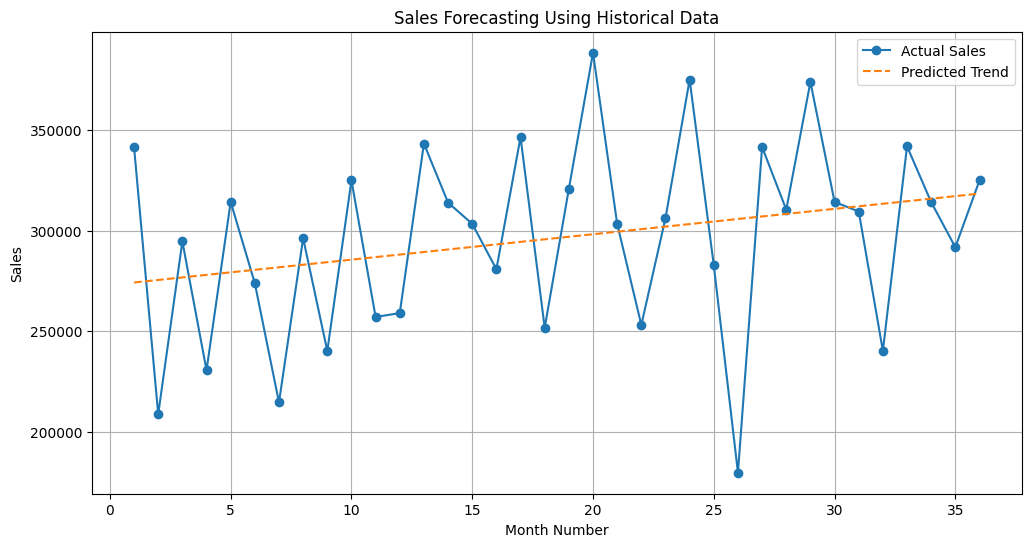

In [14]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales['Month_Number'],
    monthly_sales['Sales'],
    marker='o',
    label='Actual Sales'
)

plt.plot(
    monthly_sales['Month_Number'],
    monthly_sales['Predicted_Sales'],
    linestyle='--',
    label='Predicted Trend'
)

plt.xlabel('Month Number')
plt.ylabel('Sales')
plt.title('Sales Forecasting Using Historical Data')

plt.legend()
plt.grid(True)

plt.savefig('Sales_Prediction.png')

plt.show()

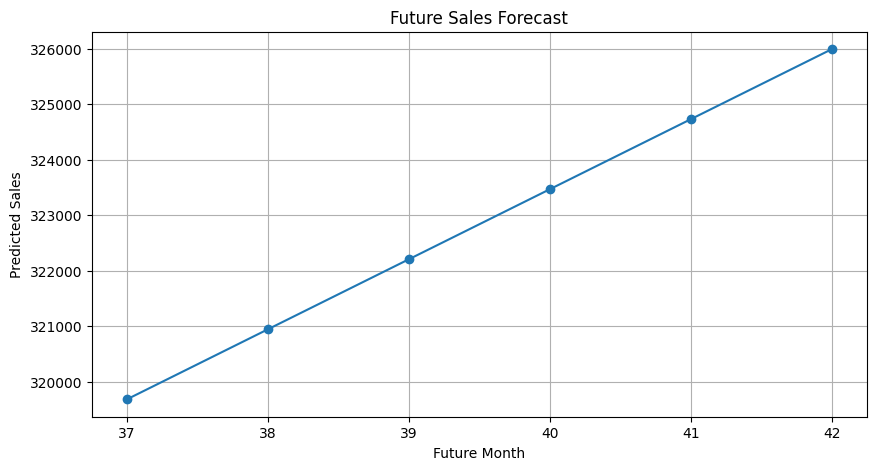

In [15]:
plt.figure(figsize=(10,5))

plt.plot(
    future_df['Month_Number'],
    future_df['Predicted Sales'],
    marker='o'
)

plt.title('Future Sales Forecast')
plt.xlabel('Future Month')
plt.ylabel('Predicted Sales')

plt.grid(True)

plt.show()